# Basic Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

In [2]:
# Load the combined prices
df_prices = pd.read_csv('prices_combined.csv', sep=';')

# Load the combined trades
df_trades = pd.read_csv('trades_combined.csv', sep=';')

# Display the first few rows to verify
display(df_prices.head())
display(df_trades.head())


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
1,0,0,VEV_6000,0,25,NaN,NaN,NaN,NaN,1,25,NaN,NaN,NaN,NaN,0.5,0.0
2,0,0,VEV_5100,169,19,NaN,NaN,NaN,NaN,174,19,NaN,NaN,NaN,NaN,171.5,0.0
3,0,0,VEV_4000,1240,7,1237.0,24.0,NaN,NaN,1260,7,1263.0,24.0,NaN,NaN,1250.0,0.0
4,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,2500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4,0
1,2900,NaN,NaN,VEV_5400,XIRECS,22.0,3,0
2,2900,NaN,NaN,VEV_5500,XIRECS,8.0,3,0
3,2900,NaN,NaN,VEV_6000,XIRECS,0.0,3,0
4,2900,NaN,NaN,VEV_6500,XIRECS,0.0,3,0


In [3]:
# Filter prices (column is 'product')
df_prices = df_prices[df_prices['product'] == 'VELVETFRUIT_EXTRACT'].copy().sort_values('timestamp')

# Filter trades (column is 'symbol')
df_trades = df_trades[df_trades['symbol'] == 'VELVETFRUIT_EXTRACT'].copy().sort_values('timestamp')

# Verify the filter
display(df_prices.head())
display(df_trades.head())


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
11,0,0,VELVETFRUIT_EXTRACT,5247,67,NaN,NaN,NaN,NaN,5253,67,NaN,NaN,NaN,NaN,5250.0,0.0
21,0,100,VELVETFRUIT_EXTRACT,5248,69,NaN,NaN,NaN,NaN,5253,23,5254.0,46.0,NaN,NaN,5250.5,0.0
33,0,200,VELVETFRUIT_EXTRACT,5248,20,5247.0,40.0,NaN,NaN,5253,60,NaN,NaN,NaN,NaN,5250.5,0.0
36,0,300,VELVETFRUIT_EXTRACT,5248,24,5247.0,40.0,NaN,NaN,5253,64,NaN,NaN,NaN,NaN,5250.5,0.0
48,0,400,VELVETFRUIT_EXTRACT,5248,25,5247.0,37.0,NaN,NaN,5253,62,NaN,NaN,NaN,NaN,5250.5,0.0


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,2500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4,0
5,5200,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5236.0,3,0
6,5500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5241.0,8,0
9,9300,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5229.0,6,0
12,11900,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5237.0,4,0


In [4]:
# To get unique buyers
unique_buyers = df_trades['buyer'].unique()
unique_buyers_numbers = [int(buyer.split()[1]) for buyer in unique_buyers if pd.notna(buyer)]
print("Unique Buyers:", unique_buyers)

# To get unique sellers
unique_sellers = df_trades['seller'].unique()
unique_sellers_numbers = [int(seller.split()[1]) for seller in unique_sellers if pd.notna(seller)]
print("Unique Sellers:", unique_sellers)

# To get unique values from both combined
unique_participants = pd.unique(df_trades[['buyer', 'seller']].values.ravel('K'))
print("All Unique Participants:", unique_participants)


Unique Buyers: <StringArray>
[nan, 'Mark 55', 'Mark 67', 'Mark 01', 'Mark 14', 'Mark 22', 'Mark 49']
Length: 7, dtype: str
Unique Sellers: <StringArray>
[nan, 'Mark 01', 'Mark 49', 'Mark 55', 'Mark 22', 'Mark 14']
Length: 6, dtype: str
All Unique Participants: [nan 'Mark 55' 'Mark 67' 'Mark 01' 'Mark 14' 'Mark 22' 'Mark 49']


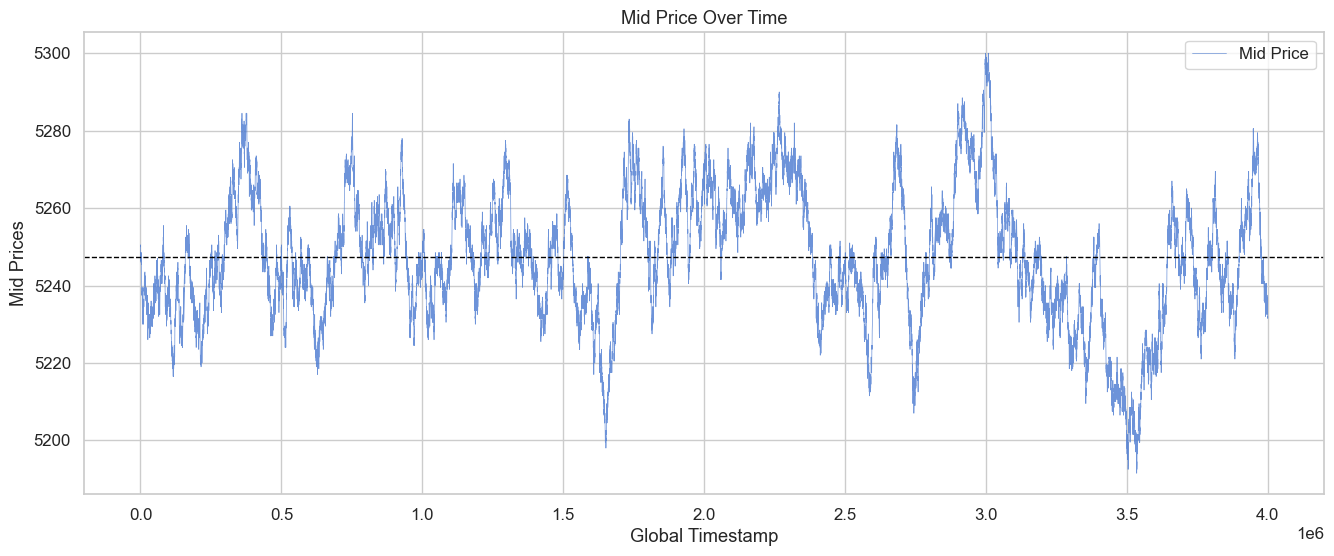

In [9]:
plt.figure(figsize=(16, 6))
plt.plot(df_prices['timestamp'], df_prices['mid_price'], label='Mid Price', alpha=0.8, linewidth=0.5)
plt.axhline(df_prices['mid_price'].mean(), color='black', linestyle='--', linewidth = 1)
plt.title('Mid Price Over Time')
plt.xlabel('Global Timestamp')
plt.ylabel('Mid Prices')
plt.legend()
plt.show()

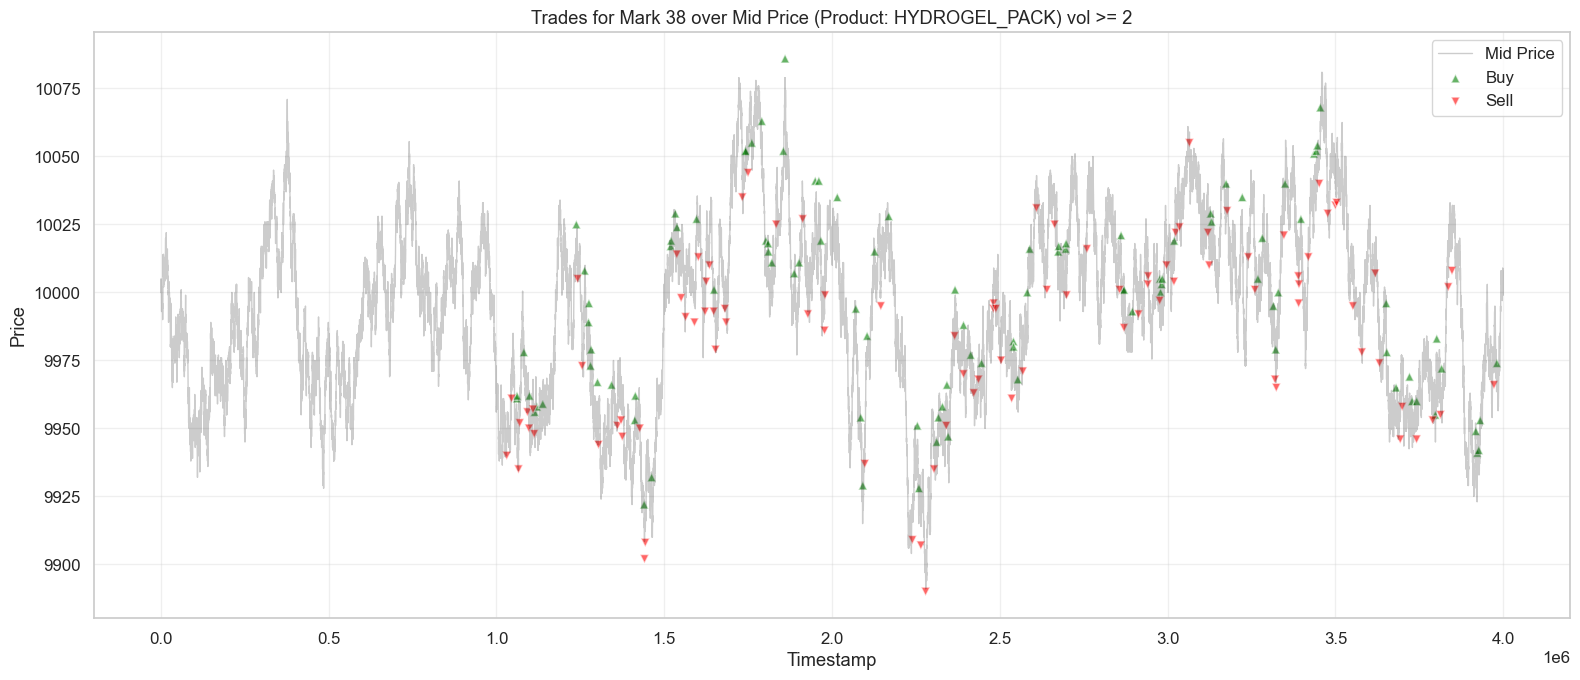

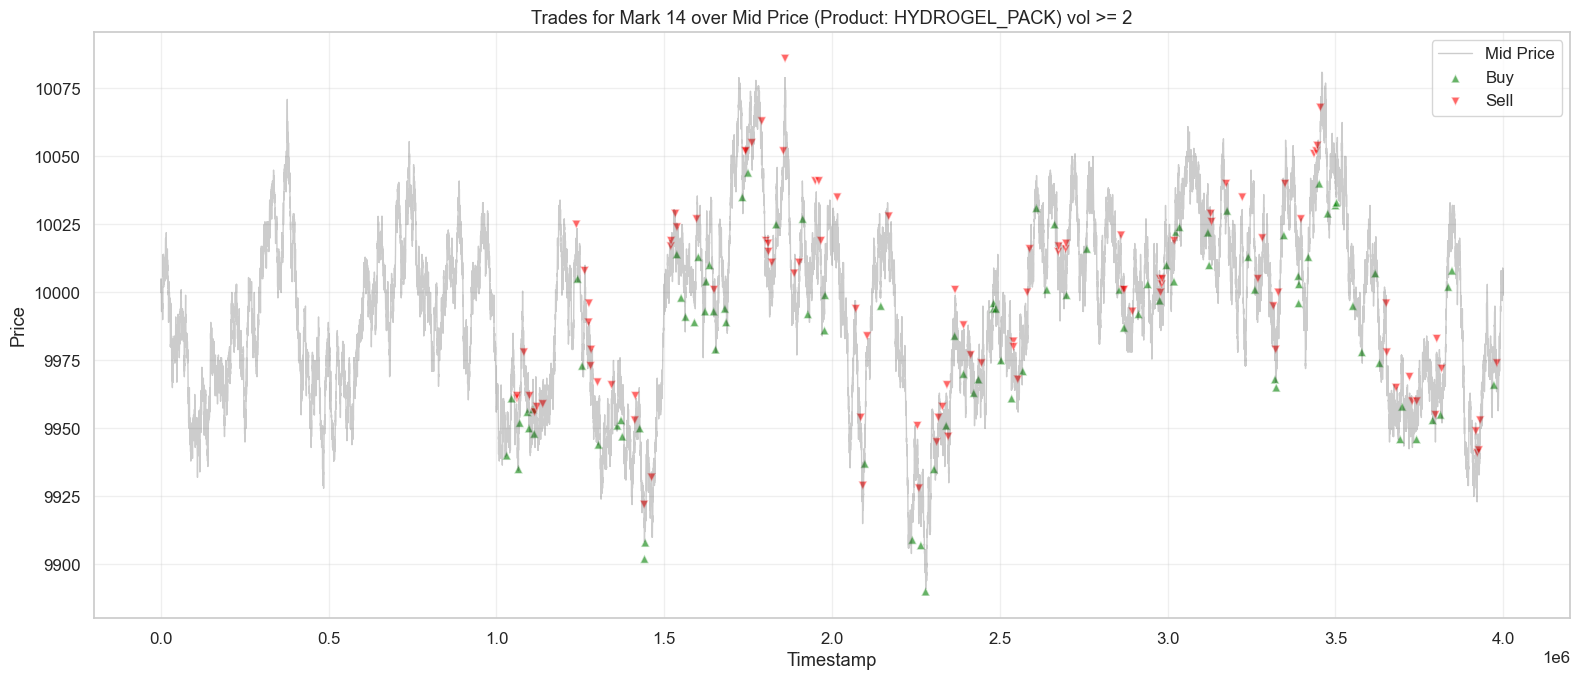

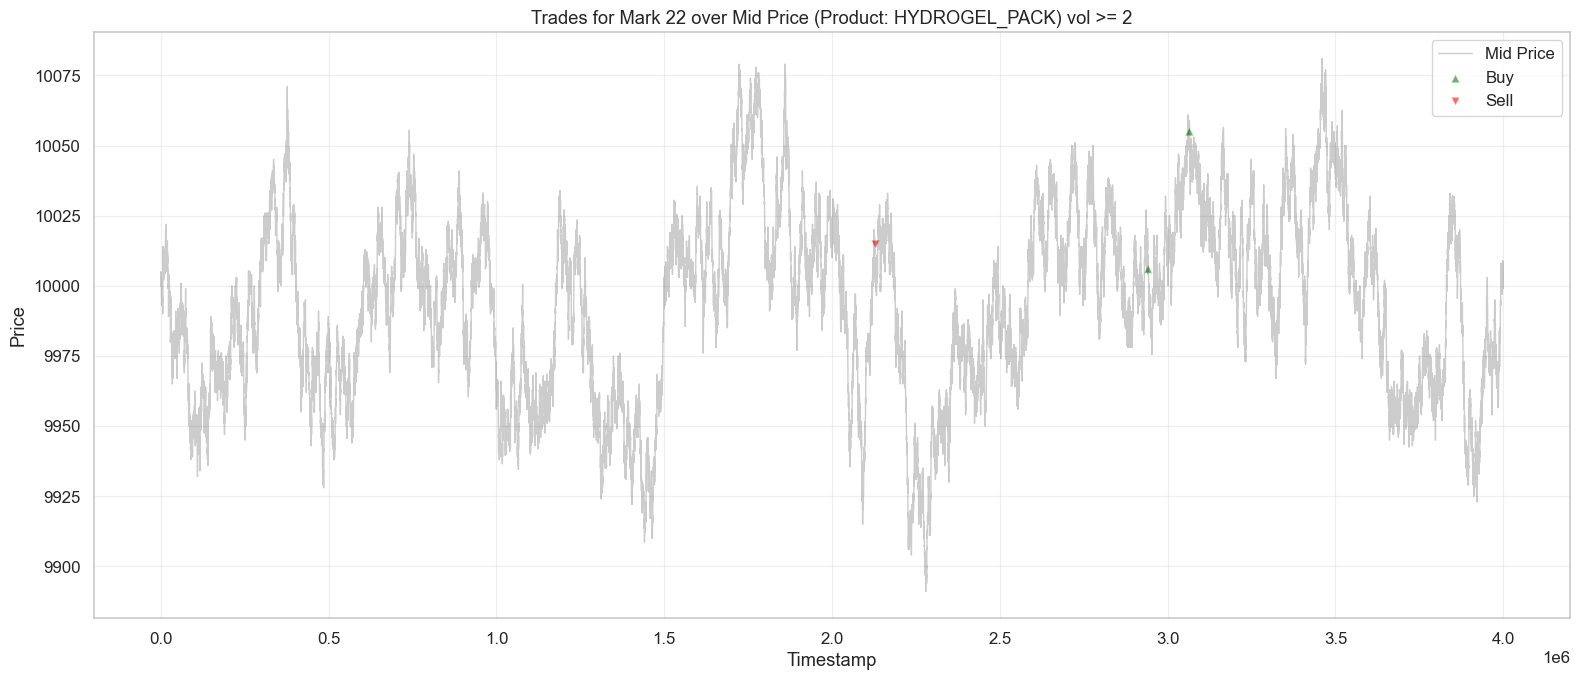

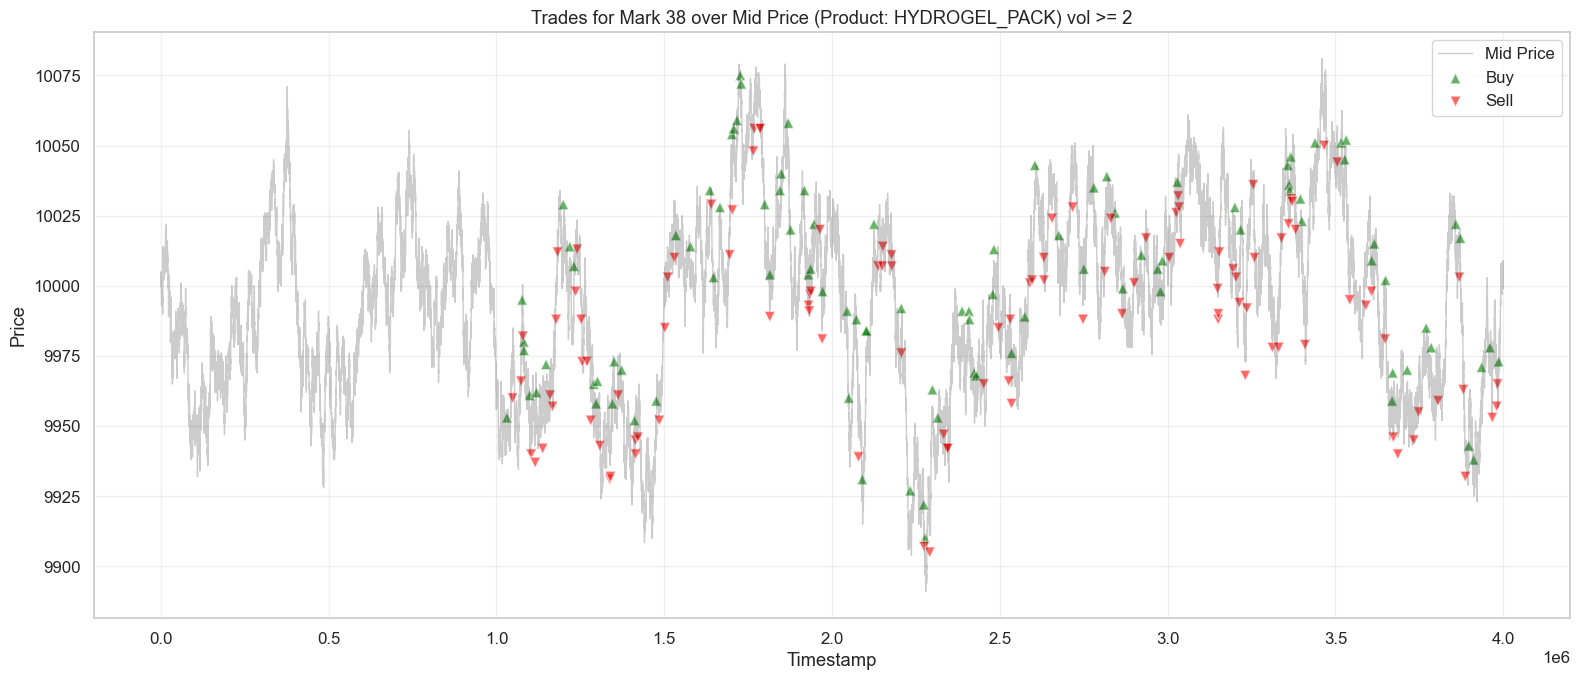

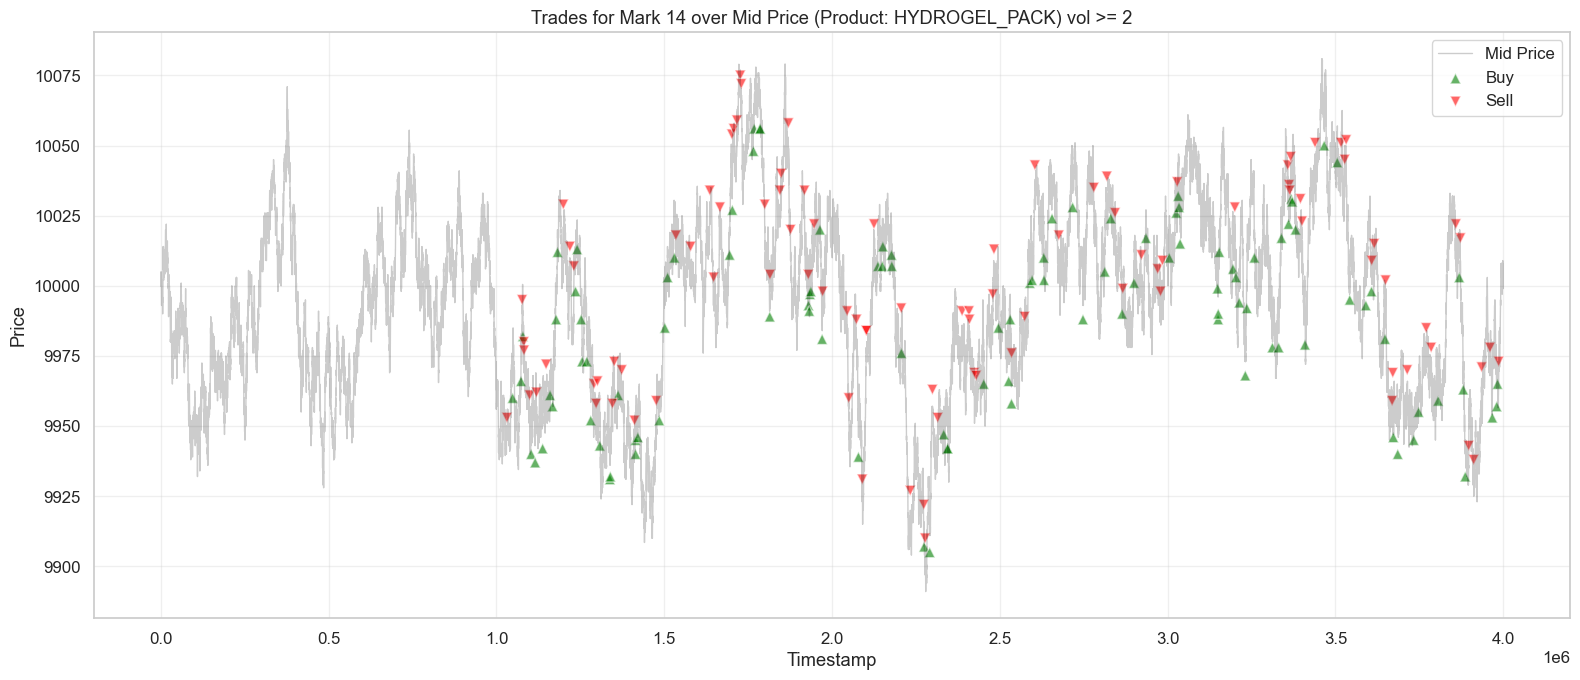

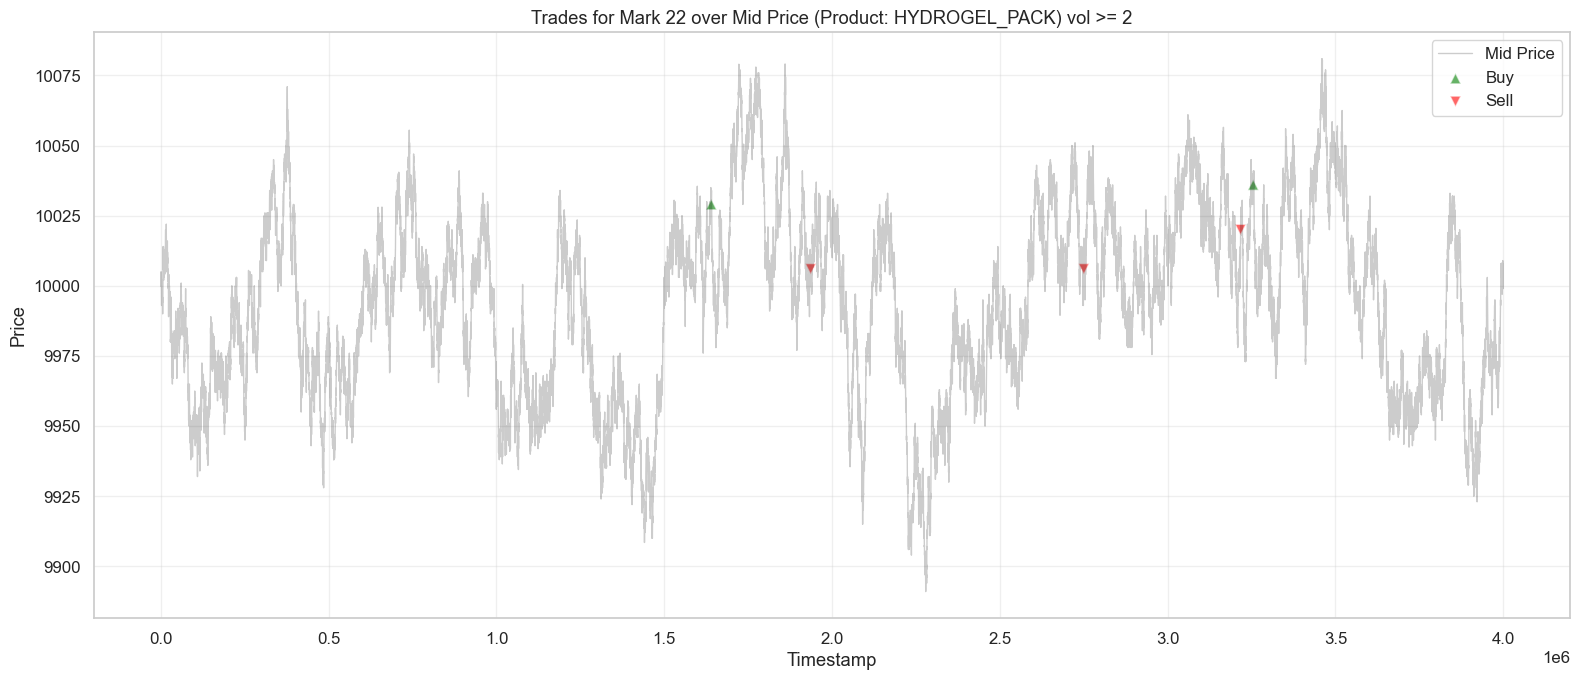

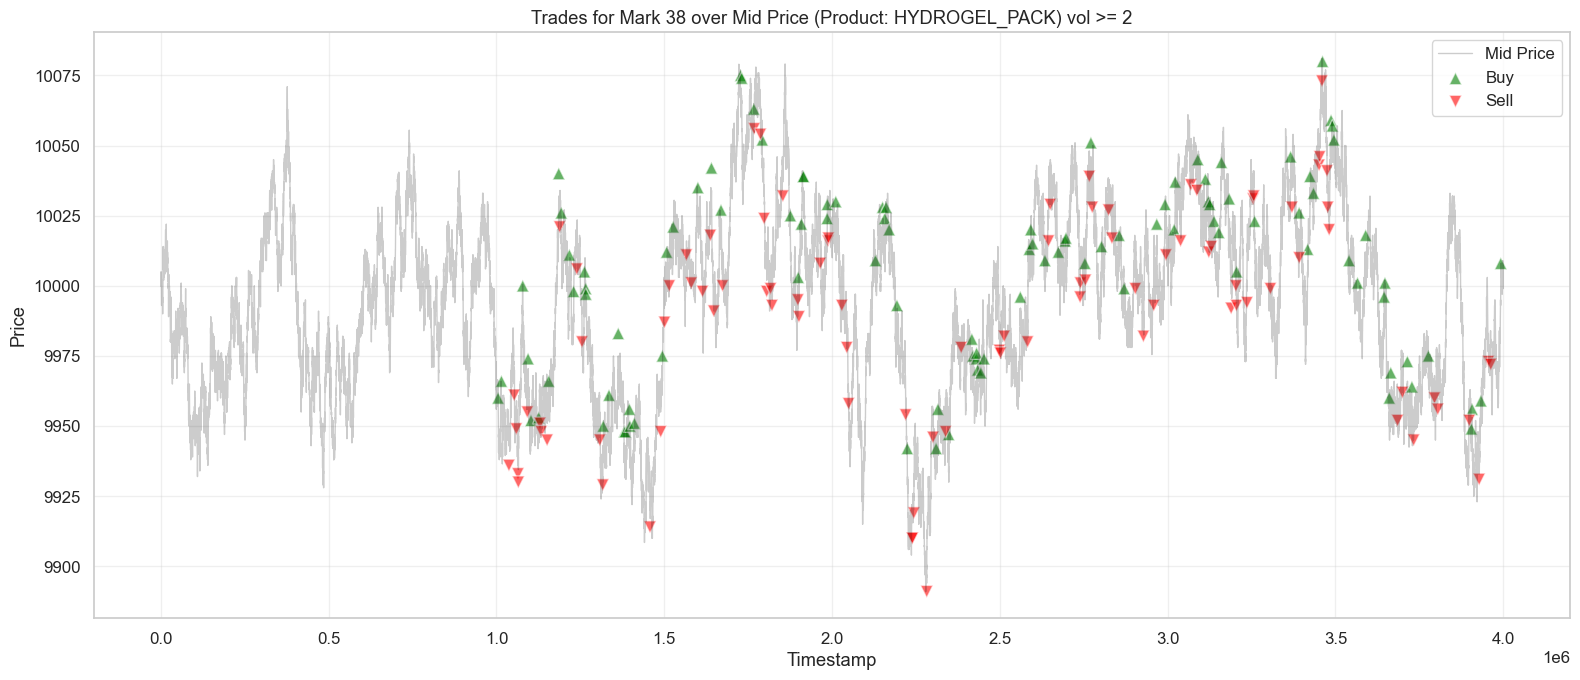

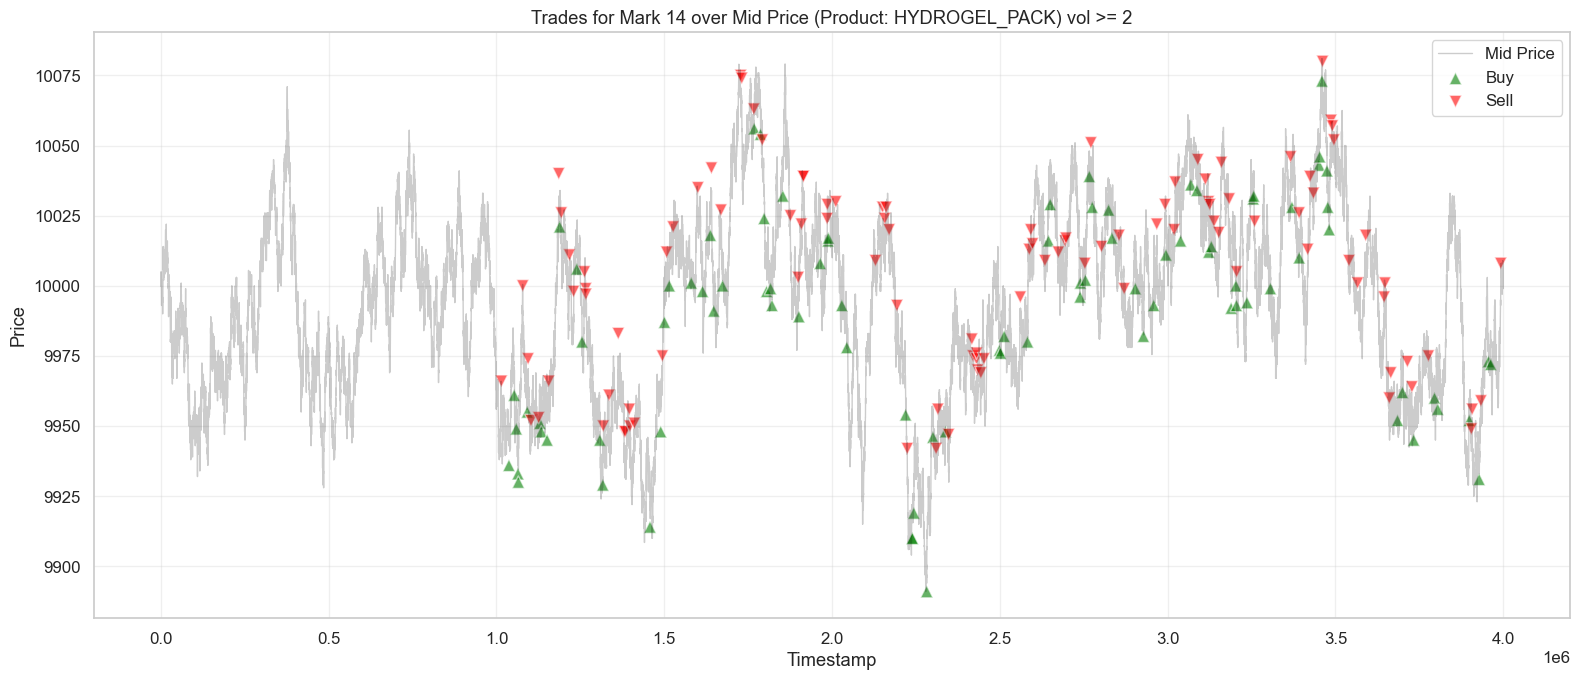

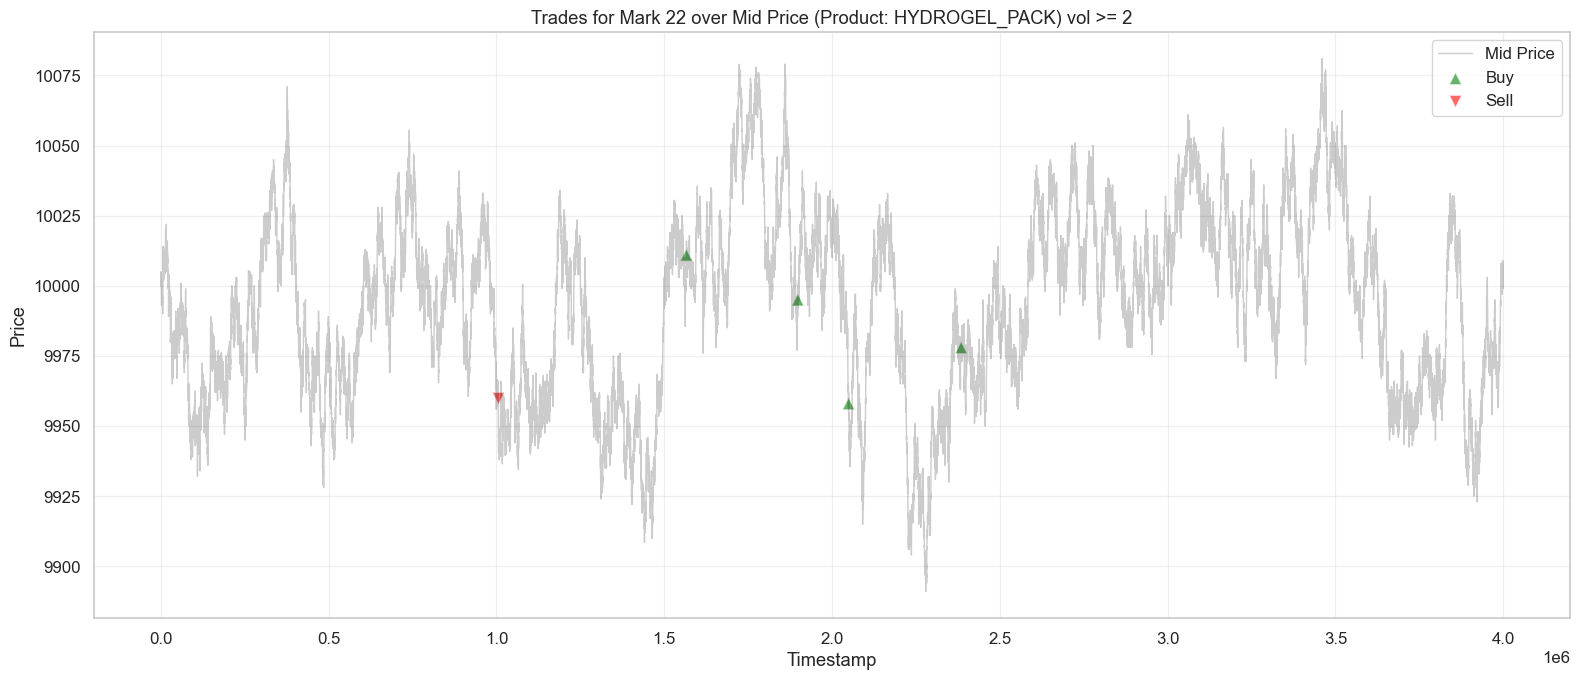

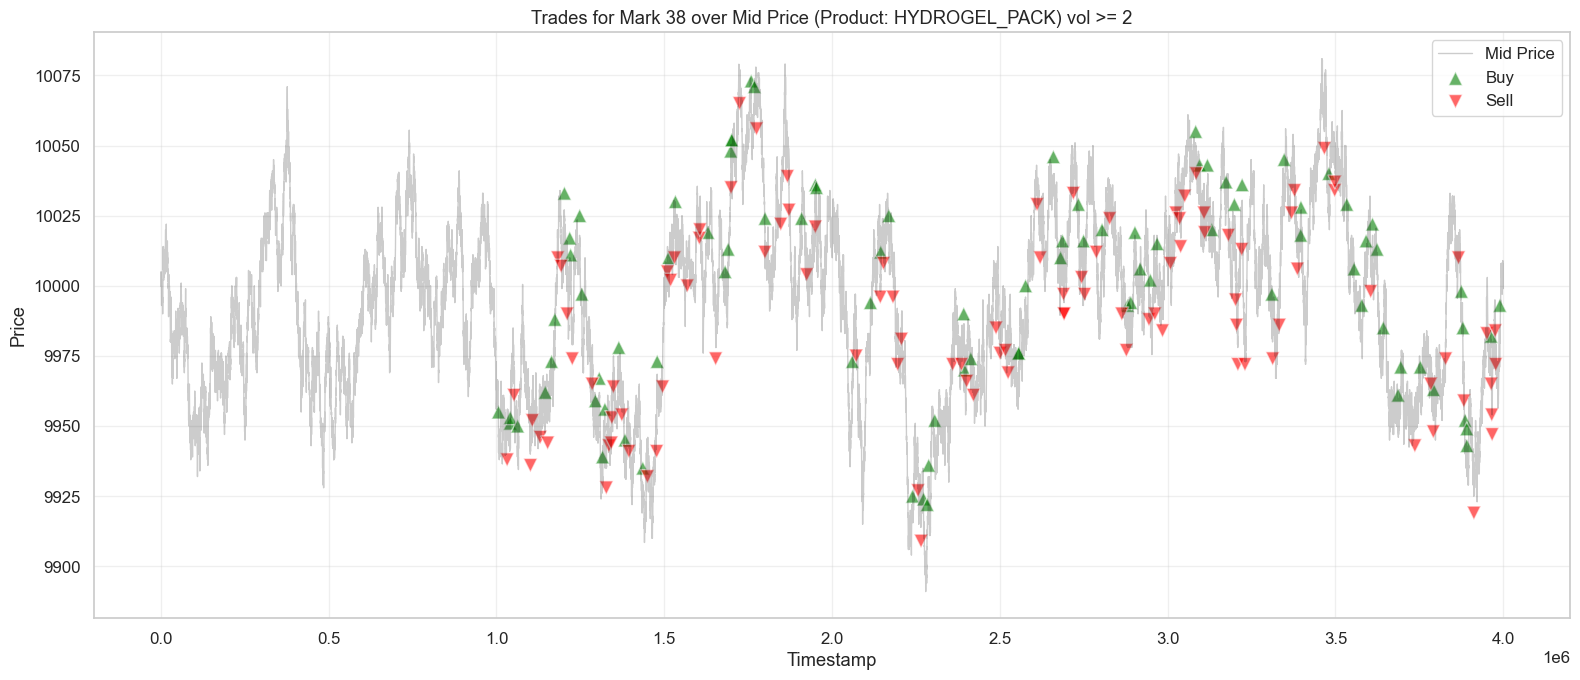

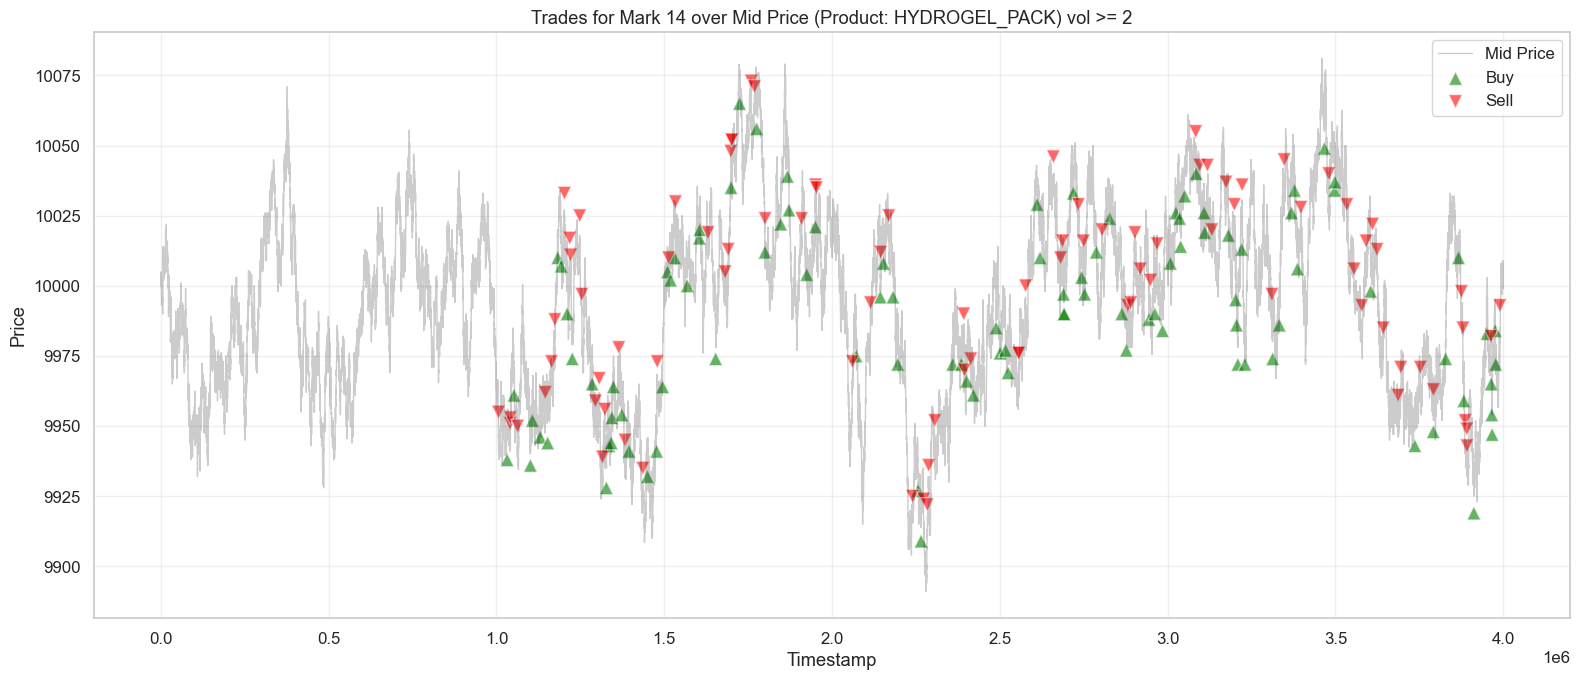

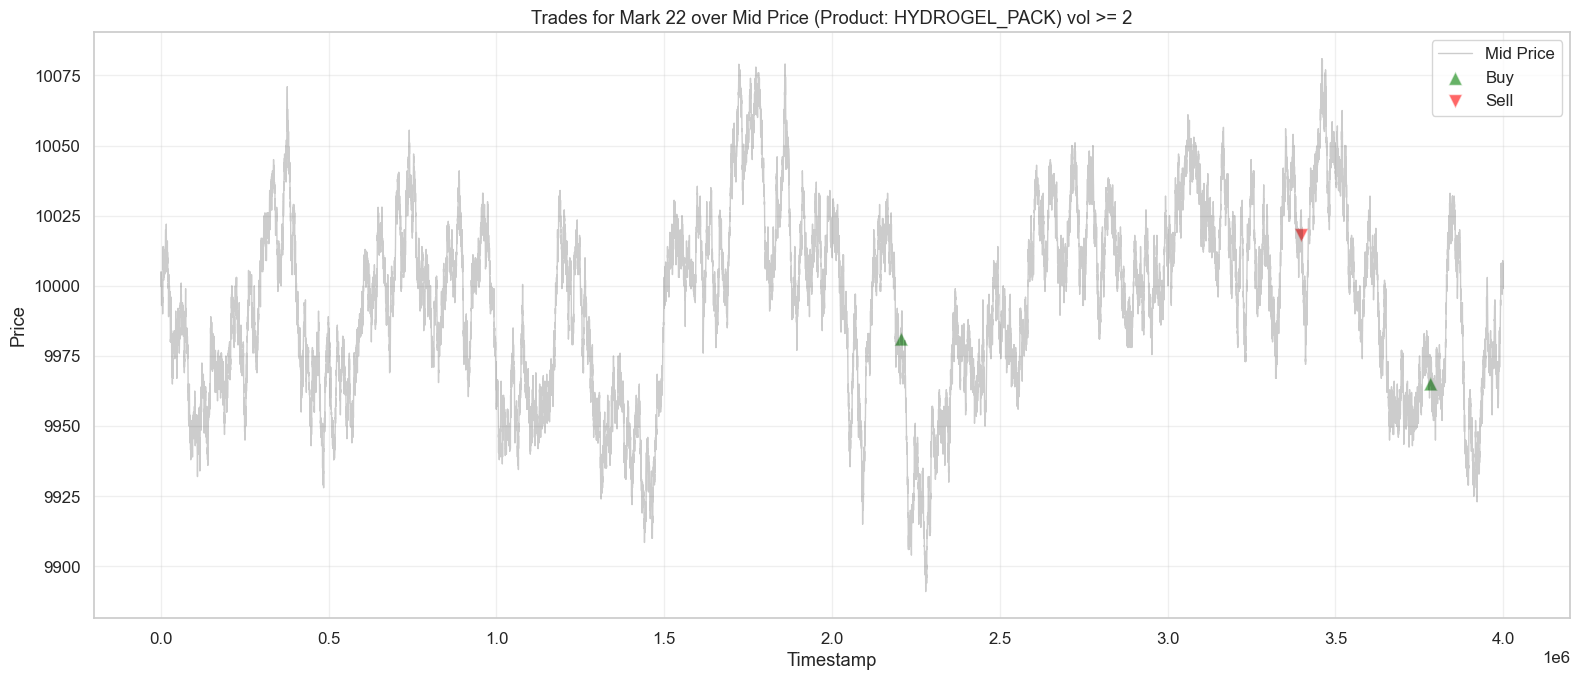

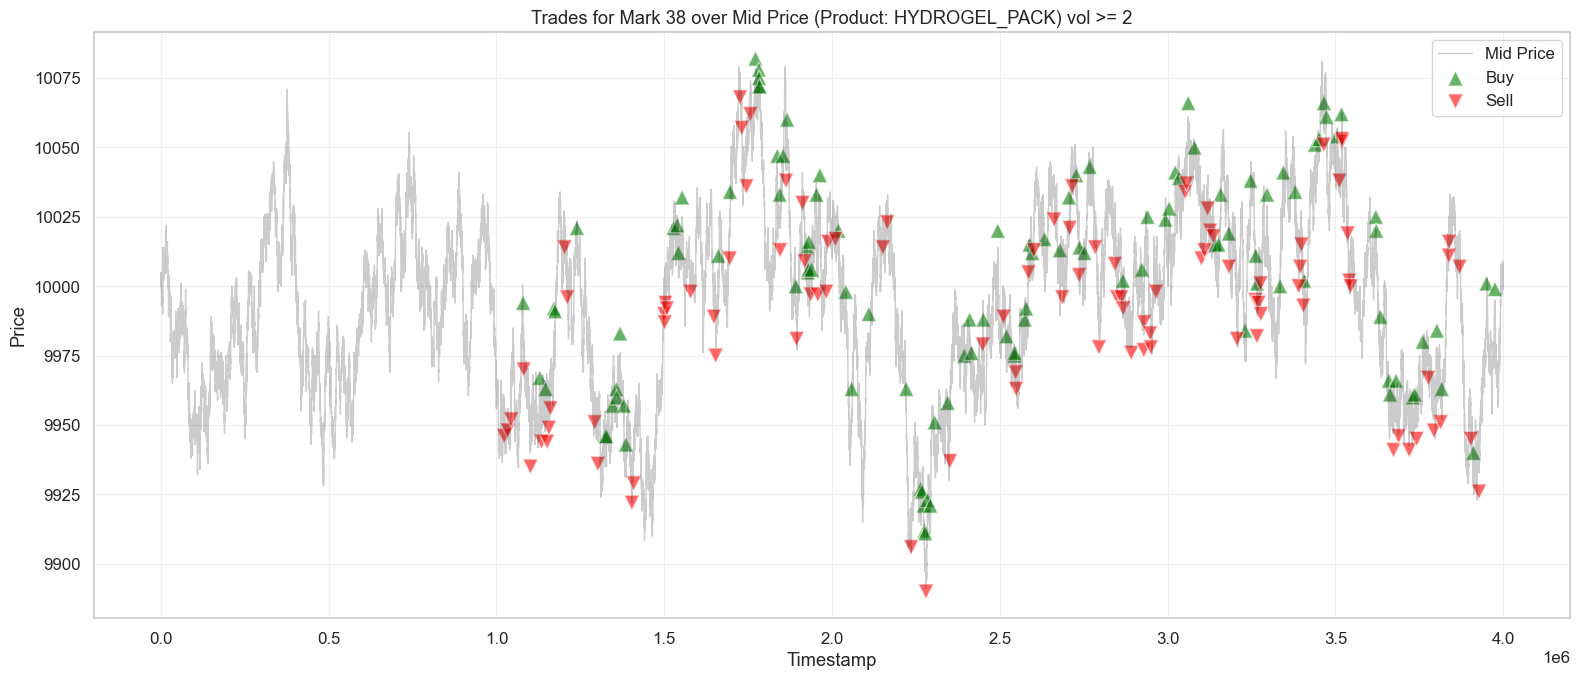

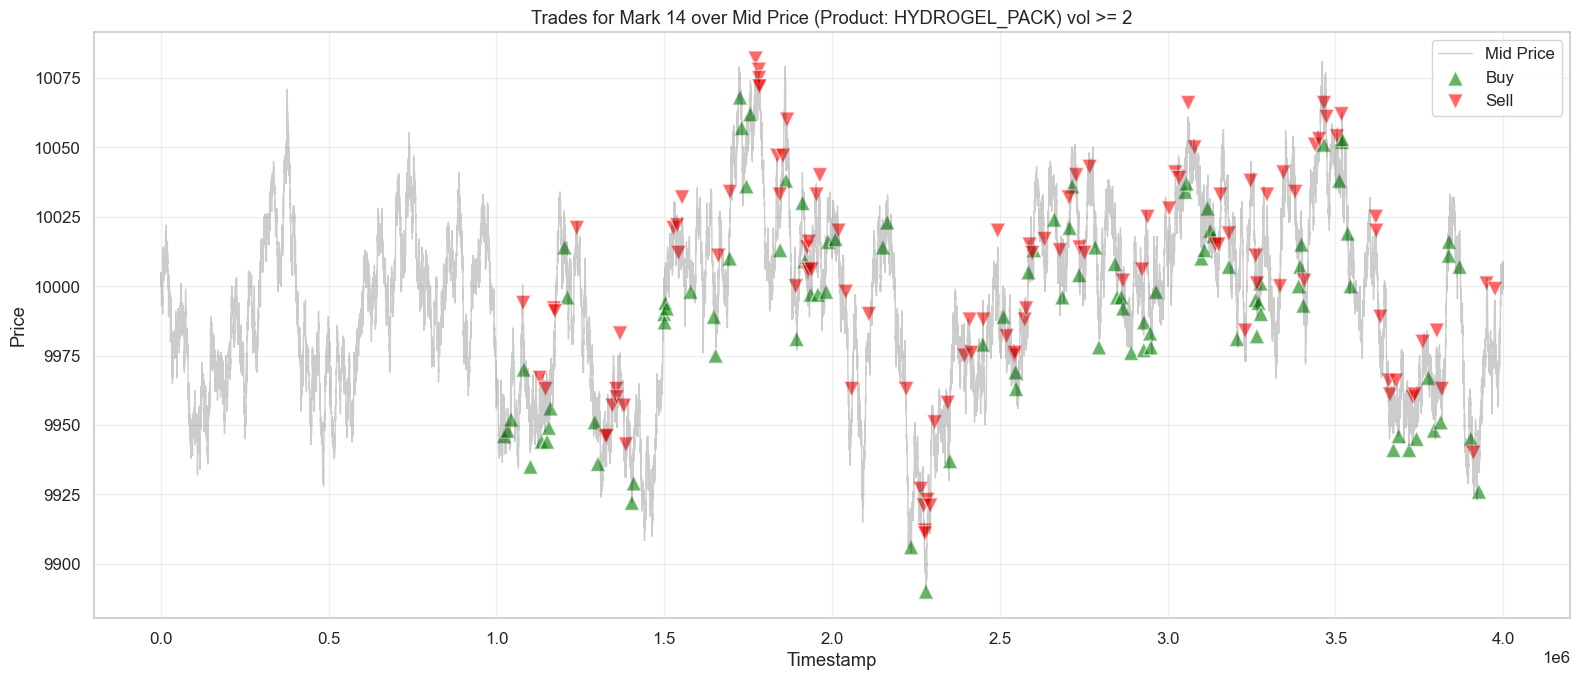

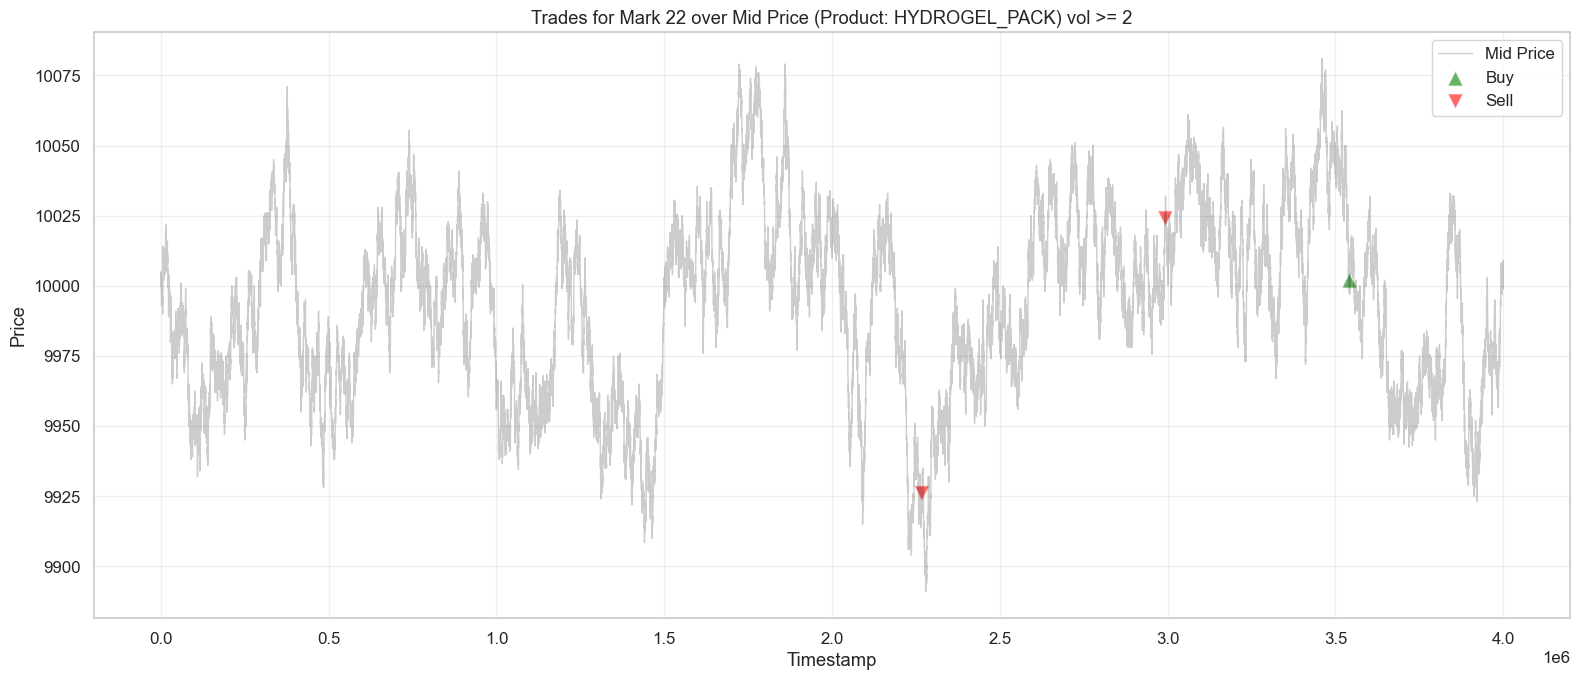

In [39]:
# 2. Identify all unique traders (ignoring empty strings/NaNs)
all_traders = pd.concat([df_trades['buyer'], df_trades['seller']]).dropna().unique()
traders = [t for t in all_traders if str(t).strip() != '']
MIN_SIZE = 2
MAX_SIZE = 6

#df_trades_large = df_trades[df_trades['quantity'] >= MIN_SIZE]
# df_trades_large = df_trades[df_trades['quantity'] <= MAX_SIZE]

if not traders:
    print("No named traders found in the buyer/seller columns.")
else:
    for i in range(MIN_SIZE, MAX_SIZE + 1):
        for trader in traders:
            df_trades_large = df_trades[df_trades['quantity'] == i]
            plt.figure(figsize=(16, 7))
            
            # Plot the Mid Price as a baseline
            plt.plot(df_prices['timestamp'], df_prices['mid_price'], 
                    label='Mid Price', color='black', alpha=0.2, linewidth=1)
            
            # Filter trades where the trader is the BUYER (Green)
            buys = df_trades_large[df_trades_large['buyer'] == trader]
            if not buys.empty:
                plt.scatter(buys['timestamp'], buys['price'], 
                            s=buys['quantity'] * 20,  # Scale size by volume
                            c='green', label='Buy', alpha=0.6, edgecolors='white', marker='^')
            
            # Filter trades where the trader is the SELLER (Red)
            sells = df_trades_large[df_trades_large['seller'] == trader]
            if not sells.empty:
                plt.scatter(sells['timestamp'], sells['price'], 
                            s=sells['quantity'] * 20,  # Scale size by volume
                            c='red', label='Sell', alpha=0.6, edgecolors='white', marker='v')
            
            plt.title(f"Trades for {trader} over Mid Price (Product: HYDROGEL_PACK) vol >= {MIN_SIZE}")
            plt.xlabel("Timestamp")
            plt.ylabel("Price")
            plt.legend(loc='upper right')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
